In [ ]:
import numpy as np
import pandas as pd
from sympy import limit
import wandb

api = wandb.Api(
    api_key="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"
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={
        # "display_name": {"$regex": "trained_on_.._eval_on_.._..?_shot_.+"},
        # "config.dataset": "ukr_rus_twitter",
        # "config.task_name": "neighbor_matching",
    },
    order="-created_at",
    per_page=10,
    # limit to 10:
    lazy=False
)

rows = []
for run in runs[:50]:
    attrs = getattr(run, "_attrs", {}) or {}
    params = ((attrs.get("config") or {}).get("params") or {})
    # print(params)

    rows.append({
        "run_id": attrs.get("name"),
        "display_name": attrs.get("displayName"),
        "state": attrs.get("state"),
        "dataset": params.get("dataset"),
        "task_name": params.get("task_name"),
        "prefix": params.get("prefix"),
        "graph_filename": params.get("graph_filename"),
        "pretrained_model_run": params.get("pretrained_model_run"),
        "n_shots": params.get("n_shots"),
        "n_query": params.get("n_query"),
        "midterm_feature_subset": params.get("midterm_feature_subset"),
        "test_accuracy": (attrs.get("summaryMetrics") or {}).get("test_accuracy"),
        "test_f1": (attrs.get("summaryMetrics") or {}).get("test_f1"),
        "test_roc_auc": (attrs.get("summaryMetrics") or {}).get("test_roc_auc"),
    })

df = pd.DataFrame(rows)

In [ ]:
df['train1_dataset'] = df.pretrained_model_run.str.extract('train1_(ukr_rus_twitter|midterm)_')
df['train1_task'] = df.pretrained_model_run.str.extract('train1_.+_(nm|pl|lp)_')
df['eval1_dataset'] = df.dataset
df['eval1_task'] = df.task_name.map({
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
})

cols = [
    'train1_dataset', 'train1_task', 'eval1_dataset', 
    'eval1_task', 'n_shots', 
    'test_accuracy', 'test_f1', 'test_roc_auc']

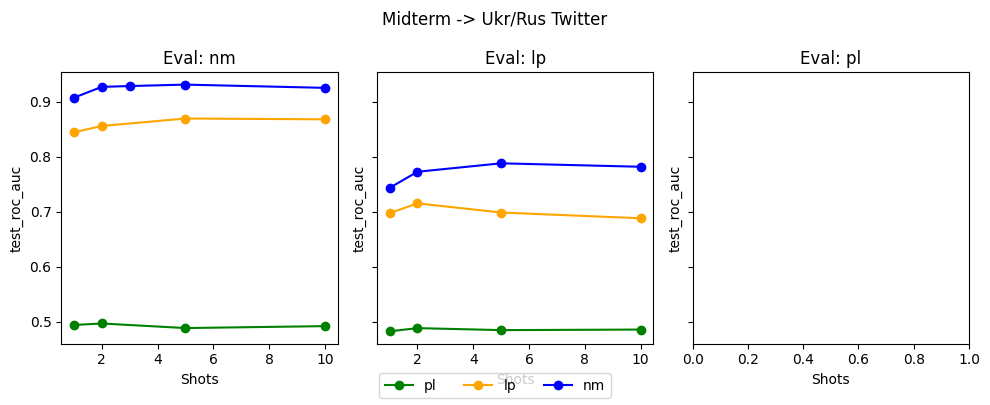

In [ ]:
import matplotlib.pyplot as plt

df_mt_to_ukr = df[df['train1_dataset'].eq('midterm') & df['eval1_dataset'].eq('ukr_rus_twitter')][cols]

# eval_tasks = df_mt_to_ukr["eval1_task"].unique()
eval_tasks = ['nm', 'lp', 'pl']

colors = {
    "nm": "blue",
    "lp": "orange",
    "pl": "green"
}

fig, axes = plt.subplots(1, len(eval_tasks), figsize=(10, 4), sharey=True)

# If only one eval_task, axes isn't a list
# if len(eval_tasks) == 1:
#     axes = [axes]

for ax, eval_task in zip(axes, eval_tasks):
    subset = df_mt_to_ukr[df_mt_to_ukr["eval1_task"] == eval_task]

    for train_task in subset["train1_task"].unique():
        sub = subset[subset["train1_task"] == train_task].sort_values("n_shots")
        ax.plot(sub["n_shots"], sub["test_roc_auc"], marker='o', label=train_task, color=colors.get(train_task))
    
    ax.set_title(f"Eval: {eval_task}")
    ax.set_xlabel("Shots")
    ax.set_ylabel("test_roc_auc")

# Single legend for all
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)

# title
fig.suptitle("Midterm -> Ukr/Rus Twitter")

plt.tight_layout()
plt.show()

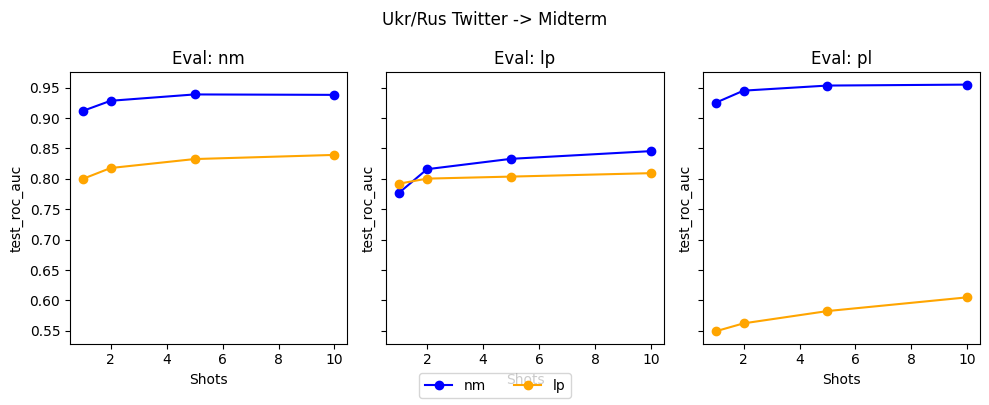

In [152]:
df_ukr_to_mt = df[cols][
    df['train1_dataset'].eq('ukr_rus_twitter') & 
    df['eval1_dataset'].eq('midterm')
    ]

# eval_tasks = df_ukr_to_mt["eval1_task"].unique()

fig, axes = plt.subplots(1, len(eval_tasks), figsize=(10, 4), sharey=True)

# If only one eval_task, axes isn't a list
if len(eval_tasks) == 1:
    axes = [axes]

for ax, eval_task in zip(axes, eval_tasks):
    subset = df_ukr_to_mt[df_ukr_to_mt["eval1_task"] == eval_task]
    
    for train_task in subset["train1_task"].unique():
        sub = subset[subset["train1_task"] == train_task].sort_values("n_shots")
        ax.plot(sub["n_shots"], sub["test_roc_auc"], marker='o', label=train_task, color=colors.get(train_task))
    
    ax.set_title(f"Eval: {eval_task}")
    ax.set_xlabel("Shots")
    ax.set_ylabel("test_roc_auc")

# Single legend for all
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)

# title
fig.suptitle("Ukr/Rus Twitter -> Midterm")

plt.tight_layout()
plt.show()

